# 10 · Evaluación experimental, estabilidad y robustez del recomendador multimodal

Este notebook evalúa de forma independiente el recomendador construido en los notebooks anteriores.

La unidad experimental es una alternativa **barrio × destino × modo de transporte**. El objetivo no es volver a construir el recomendador, sino comprobar de forma reproducible que sus decisiones:

- mantienen la **eficiencia de Pareto**;
- reaccionan de forma coherente a las **preferencias precio–tiempo**;
- son razonablemente **estables** ante pequeños cambios de pesos;
- son **robustas** ante restricciones y perturbaciones moderadas de los datos;
- presentan **diversidad** suficiente para que la personalización tenga un efecto real;
- se comportan de forma consistente en `TRANSIT`, `WALK`, `BICYCLE` y `CAR`.

Se comparan cinco estrategias:

1. **Pareto + suma ponderada**, método principal.
2. **Suma ponderada sin filtro Pareto**.
3. **Distancia al punto ideal**.
4. **Alternativa más barata**.
5. **Alternativa más rápida**.

> Los umbrales de las hipótesis son criterios operativos definidos para este experimento. No se presentan como leyes universales de calidad de un sistema recomendador.


## 1. Importaciones


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 180)


## 2. Reproducibilidad y configuración experimental


In [3]:
RANDOM_SEED = 42

# Debe permanecer en False para la ejecución final del TFG.
# True reduce la rejilla y las iteraciones Monte Carlo para pruebas rápidas.
FAST_MODE = False

TOP_K = 5
WEIGHT_STEP = 0.05 if FAST_MODE else 0.01
MONTE_CARLO_ITERATIONS = 40 if FAST_MODE else 250
NOISE_LEVELS = [0.02, 0.05, 0.10]

FLOAT_TOLERANCE = 1e-10

EXPECTED_TRANSPORT_MODES = {
    "TRANSIT",
    "WALK",
    "BICYCLE",
    "CAR",
}

print("Semilla aleatoria:", RANDOM_SEED)
print("FAST_MODE:", FAST_MODE)
print("Paso de la rejilla de pesos:", WEIGHT_STEP)
print("Iteraciones Monte Carlo por escenario:", MONTE_CARLO_ITERATIONS)


Semilla aleatoria: 42
FAST_MODE: False
Paso de la rejilla de pesos: 0.01
Iteraciones Monte Carlo por escenario: 250


## 3. Localización del proyecto y archivos


In [4]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto a partir del directorio actual."""

    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


In [5]:
PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = RESULTS_DIR / "pareto_by_destination_mode.csv"

METHOD_DETAIL_PATH = RESULTS_DIR / "evaluation_multimodal_method_comparison_detail.csv"
METHOD_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_method_comparison_summary.csv"
METHOD_MODE_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_method_summary_by_mode.csv"

WEIGHT_GRID_PATH = RESULTS_DIR / "evaluation_multimodal_weight_stability_grid.csv"
WEIGHT_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_weight_stability_summary.csv"
WEIGHT_INTERVALS_PATH = RESULTS_DIR / "evaluation_multimodal_weight_stability_intervals.csv"

CONSTRAINT_DETAIL_PATH = RESULTS_DIR / "evaluation_multimodal_constraint_robustness.csv"
CONSTRAINT_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_constraint_robustness_summary.csv"

NOISE_FREQUENCY_PATH = RESULTS_DIR / "evaluation_multimodal_noise_winner_frequency.csv"
NOISE_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_noise_robustness_summary.csv"
NOISE_MODE_SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_noise_summary_by_mode.csv"

DIVERSITY_PATH = RESULTS_DIR / "evaluation_multimodal_diversity_summary.csv"
PROFILE_DEPENDENCE_PATH = RESULTS_DIR / "evaluation_multimodal_profile_dependence.csv"

HYPOTHESES_PATH = RESULTS_DIR / "evaluation_multimodal_hypotheses.csv"
VALIDATION_PATH = RESULTS_DIR / "evaluation_multimodal_validation_report.csv"
SUMMARY_PATH = RESULTS_DIR / "evaluation_multimodal_summary.csv"

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "No existe data/results/pareto_by_destination_mode.csv. "
        "Ejecuta primero el notebook 08 multimodal."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Archivo de entrada:", INPUT_PATH.relative_to(PROJECT_ROOT))
print("Carpeta de resultados:", RESULTS_DIR.relative_to(PROJECT_ROOT))


Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Archivo de entrada: data\results\pareto_by_destination_mode.csv
Carpeta de resultados: data\results


## 4. Carga, contrato y validación inicial

El notebook recibe el resultado completo del análisis de Pareto del notebook 08. Cada fila debe representar una alternativa única:

> **barrio × destino × modo de transporte**

Las comparaciones y normalizaciones se realizan siempre dentro de cada grupo **destino × modo**, evitando mezclar escalas de movilidad distintas.


In [6]:
data = pd.read_csv(INPUT_PATH)

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

KEY_COLUMNS = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
]

ALT_KEY = [
    "zone_key",
    "destination_id",
    "transport_mode",
]

GROUP_COLUMNS = [
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
]

REQUIRED_COLUMNS = KEY_COLUMNS + [
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
    "price_normalized",
    "time_normalized",
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in data.columns
]

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias para la evaluación: "
        f"{missing_columns}"
    )


In [7]:
for column in [
    PRICE_COLUMN,
    TIME_COLUMN,
    "price_normalized",
    "time_normalized",
    "price_reliability_score",
]:
    if column in data.columns:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce",
        )

invalid_objectives = data[
    data[[PRICE_COLUMN, TIME_COLUMN]].isna().any(axis=1)
    | (data[[PRICE_COLUMN, TIME_COLUMN]] <= 0).any(axis=1)
]

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            KEY_COLUMNS + [PRICE_COLUMN, TIME_COLUMN]
        ].head(20)
    )
    raise ValueError(
        "Existen precios o tiempos nulos, no numéricos o no positivos."
    )

if data.duplicated(ALT_KEY).any():
    duplicates = data.loc[
        data.duplicated(ALT_KEY, keep=False),
        KEY_COLUMNS,
    ]
    display(duplicates.head(30))
    raise ValueError(
        "Hay combinaciones barrio–destino–modo duplicadas."
    )


In [8]:
def parse_boolean_series(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    """Convierte una columna booleana exportada a CSV de forma segura."""

    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    true_values = {"true", "1", "yes", "y", "si", "sí"}
    false_values = {"false", "0", "no", "n"}
    valid_values = true_values | false_values

    invalid_mask = normalized.notna() & ~normalized.isin(valid_values)

    if invalid_mask.any():
        invalid_examples = sorted(
            normalized.loc[invalid_mask]
            .dropna()
            .unique()
            .tolist()
        )[:10]

        raise ValueError(
            f"Valores booleanos no reconocidos en {column_name}: "
            f"{invalid_examples}"
        )

    return normalized.isin(true_values).fillna(False)


data["is_pareto"] = parse_boolean_series(
    data["is_pareto"],
    "is_pareto",
)

normalized_columns = [
    "price_normalized",
    "time_normalized",
]

if not (
    data[normalized_columns].ge(-FLOAT_TOLERANCE).all().all()
    and data[normalized_columns].le(1 + FLOAT_TOLERANCE).all().all()
):
    raise ValueError(
        "Las variables normalizadas deben encontrarse en [0, 1]."
    )


In [9]:
present_modes = set(
    data["transport_mode"]
    .astype(str)
    .unique()
)

if present_modes != EXPECTED_TRANSPORT_MODES:
    raise ValueError(
        "Los modos presentes no coinciden con los cuatro previstos. "
        f"Presentes: {sorted(present_modes)}"
    )

destination_catalog = (
    data[["destination_id", "destination_name"]]
    .drop_duplicates()
    .sort_values(["destination_name", "destination_id"])
    .reset_index(drop=True)
)

mode_catalog = (
    data[["transport_mode", "transport_mode_label"]]
    .drop_duplicates()
    .sort_values("transport_mode")
    .reset_index(drop=True)
)

group_catalog = (
    data[GROUP_COLUMNS]
    .drop_duplicates()
    .sort_values(
        ["destination_id", "transport_mode"]
    )
    .reset_index(drop=True)
)

expected_group_count = (
    len(destination_catalog)
    * len(mode_catalog)
)

if len(group_catalog) != expected_group_count:
    raise ValueError(
        "No están presentes todas las combinaciones destino–modo. "
        f"Esperadas: {expected_group_count}; presentes: {len(group_catalog)}."
    )

print("Dimensiones:", data.shape)
print("Barrios distintos:", data["zone_key"].nunique())
print("Destinos:", len(destination_catalog))
print("Modos:", len(mode_catalog))
print("Grupos destino–modo:", len(group_catalog))

display(group_catalog)


Dimensiones: (1457, 158)
Barrios distintos: 129
Destinos: 3
Modos: 4
Grupos destino–modo: 12


,destination_id,destination_name,transport_mode,transport_mode_label
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta
1,DEST_001,Puerta del Sol,CAR,Coche
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público
3,DEST_001,Puerta del Sol,WALK,A pie
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta
5,DEST_002,Nuevos Ministerios,CAR,Coche
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público
7,DEST_002,Nuevos Ministerios,WALK,A pie
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta
9,DEST_003,UC3M Campus de Leganés,CAR,Coche


In [10]:
coverage_summary = (
    data.groupby(
        GROUP_COLUMNS,
        as_index=False,
    )
    .agg(
        alternatives=("zone_key", "size"),
        neighborhoods=("zone_key", "nunique"),
        pareto_alternatives=("is_pareto", "sum"),
        price_min=(PRICE_COLUMN, "min"),
        price_median=(PRICE_COLUMN, "median"),
        price_max=(PRICE_COLUMN, "max"),
        time_min=(TIME_COLUMN, "min"),
        time_median=(TIME_COLUMN, "median"),
        time_max=(TIME_COLUMN, "max"),
    )
)

coverage_summary["pareto_percentage"] = (
    100
    * coverage_summary["pareto_alternatives"]
    / coverage_summary["alternatives"]
)

display(coverage_summary)


,destination_id,destination_name,transport_mode,transport_mode_label,alternatives,neighborhoods,pareto_alternatives,price_min,price_median,price_max,time_min,time_median,time_max,pareto_percentage
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,129,14,1909.6,4878.72,14108.83,3.700000,68.350000,183.950000,10.852713
1,DEST_001,Puerta del Sol,CAR,Coche,121,121,14,1909.6,4789.99,14108.83,9.216667,25.166667,63.850000,11.570248
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,119,13,1909.6,4736.60,14108.83,56.366667,117.600000,244.516667,10.924370
3,DEST_001,Puerta del Sol,WALK,A pie,128,128,16,1909.6,4884.51,14108.83,3.700000,168.916667,435.816667,12.500000
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,129,16,1909.6,4878.72,14108.83,10.500000,75.616667,164.616667,12.403101
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,121,18,1909.6,4789.99,14108.83,5.983333,25.083333,65.216667,14.876033
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,124,10,1909.6,4787.97,14108.83,44.966667,120.800000,275.783333,8.064516
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,129,18,1909.6,4878.72,14108.83,21.033333,192.800000,465.916667,13.953488
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,129,4,1909.6,4878.72,14108.83,50.483333,174.516667,299.283333,3.100775
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,121,4,1909.6,4789.99,14108.83,16.016667,38.366667,76.816667,3.305785


## 5. Diseño experimental e hipótesis

Se mantienen los tres perfiles definidos en el notebook 09:

| Perfil | Peso del precio | Peso del tiempo |
|---|---:|---:|
| Prioridad al precio | 0,75 | 0,25 |
| Equilibrado | 0,50 | 0,50 |
| Prioridad al tiempo | 0,25 | 0,75 |

La evaluación se formula sobre las siguientes hipótesis operativas:

- **H1 — Eficiencia:** todas las recomendaciones del método principal deben ser Pareto-eficientes dentro del conjunto compatible.
- **H2 — Estabilidad local:** cambios pequeños y consecutivos en los pesos deben conservar, en promedio, una parte elevada del `top 5`.
- **H3 — Robustez ante ruido:** con perturbaciones del 5 %, la recomendación original debe permanecer con frecuencia dentro del `top 5`.
- **H4 — Personalización:** el cambio de perfil debe modificar la primera recomendación en al menos una combinación destino–modo.
- **H5 — Restricciones:** al endurecer precio y tiempo, los escenarios factibles deben seguir devolviendo recomendaciones Pareto-eficientes.

Criterios de contraste utilizados al final:

- H1: 100 % de eficiencia Pareto.
- H2: Jaccard medio consecutivo ≥ 0,70.
- H3: ganador original dentro del `top 5` ≥ 80 % con ruido del 5 %.
- H4: al menos un grupo destino–modo cambia de ganador entre perfiles.
- H5: 100 % de eficiencia Pareto en escenarios restringidos factibles.

Estos umbrales son transparentes y reproducibles, pero no constituyen estándares universales.


In [11]:
PROFILES = {
    "price_priority": {
        "profile_name": "Prioridad al precio",
        "price_weight": 0.75,
        "time_weight": 0.25,
    },
    "balanced": {
        "profile_name": "Perfil equilibrado",
        "price_weight": 0.50,
        "time_weight": 0.50,
    },
    "time_priority": {
        "profile_name": "Prioridad al tiempo",
        "price_weight": 0.25,
        "time_weight": 0.75,
    },
}

METHOD_LABELS = {
    "pareto_weighted": "Pareto + suma ponderada",
    "weighted_all": "Suma ponderada sin filtro",
    "ideal_distance": "Distancia al punto ideal",
    "cheapest": "Barrio más barato",
    "fastest": "Trayecto más rápido",
}

METHODS = list(METHOD_LABELS)

profile_table = pd.DataFrame(
    [
        {"profile_id": profile_id, **values}
        for profile_id, values in PROFILES.items()
    ]
)

display(profile_table)


,profile_id,profile_name,price_weight,time_weight
0,price_priority,Prioridad al precio,0.75,0.25
1,balanced,Perfil equilibrado,0.50,0.50
2,time_priority,Prioridad al tiempo,0.25,0.75


## 6. Funciones comunes de evaluación


In [12]:
def normalize_weights(
    price_weight: float,
    time_weight: float,
) -> tuple[float, float]:
    """Valida y normaliza dos pesos no negativos."""

    weights = np.asarray(
        [price_weight, time_weight],
        dtype=float,
    )

    if not np.isfinite(weights).all():
        raise ValueError("Los pesos deben ser finitos.")

    if (weights < 0).any():
        raise ValueError("Los pesos no pueden ser negativos.")

    total = weights.sum()

    if np.isclose(total, 0):
        raise ValueError(
            "Al menos uno de los pesos debe ser positivo."
        )

    return (
        float(weights[0] / total),
        float(weights[1] / total),
    )


def minmax_normalize(series: pd.Series) -> pd.Series:
    """Normalización min–max robusta."""

    numeric = pd.to_numeric(
        series,
        errors="coerce",
    ).astype(float)

    minimum = numeric.min()
    maximum = numeric.max()

    if not np.isfinite(minimum) or not np.isfinite(maximum):
        raise ValueError(
            "No se puede normalizar una serie con valores no finitos."
        )

    if np.isclose(maximum, minimum):
        return pd.Series(
            np.zeros(len(numeric), dtype=float),
            index=numeric.index,
        )

    return (
        (numeric - minimum)
        / (maximum - minimum)
    )


In [13]:
def pareto_mask_2d(
    price_values: Iterable[float],
    time_values: Iterable[float],
) -> np.ndarray:
    """
    Eficiencia Pareto para dos objetivos a minimizar.

    Un punto está dominado si existe otro con precio y tiempo no mayores
    y al menos uno de los dos estrictamente menor.
    """

    price = np.asarray(price_values, dtype=float)
    time = np.asarray(time_values, dtype=float)

    if (
        price.ndim != 1
        or time.ndim != 1
        or len(price) != len(time)
    ):
        raise ValueError(
            "Los objetivos deben ser vectores de igual longitud."
        )

    if not np.isfinite(price).all() or not np.isfinite(time).all():
        raise ValueError("Pareto no admite NaN o infinitos.")

    if len(price) == 0:
        return np.array([], dtype=bool)

    order = np.lexsort((time, price))
    sorted_price = price[order]
    sorted_time = time[order]
    efficient_sorted = np.zeros(len(price), dtype=bool)

    best_time_lower_price = np.inf
    start = 0

    while start < len(price):
        end = start + 1

        while (
            end < len(price)
            and sorted_price[end] == sorted_price[start]
        ):
            end += 1

        group_times = sorted_time[start:end]
        group_min_time = group_times.min()

        efficient_sorted[start:end] = (
            (group_times == group_min_time)
            & (group_times < best_time_lower_price)
        )

        best_time_lower_price = min(
            best_time_lower_price,
            group_min_time,
        )
        start = end

    efficient = np.zeros(len(price), dtype=bool)
    efficient[order] = efficient_sorted

    return efficient


In [14]:
def resolve_destination_id(
    source: pd.DataFrame,
    destination: str | int,
) -> str:
    """Resuelve un destino por identificador o nombre."""

    catalog = source[
        ["destination_id", "destination_name"]
    ].drop_duplicates()

    requested = str(destination).strip().casefold()

    match = catalog.loc[
        catalog["destination_id"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
        |
        catalog["destination_name"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
    ]

    if match.empty:
        raise KeyError(
            f"Destino no encontrado: {destination}"
        )

    if len(match) > 1:
        raise ValueError(
            "El destino no es unívoco. Utiliza destination_id."
        )

    return str(match.iloc[0]["destination_id"])


def resolve_transport_mode(
    source: pd.DataFrame,
    transport_mode: str,
) -> str:
    """Resuelve un modo por código o etiqueta."""

    catalog = source[
        ["transport_mode", "transport_mode_label"]
    ].drop_duplicates()

    requested = (
        str(transport_mode)
        .strip()
        .casefold()
    )

    match = catalog.loc[
        catalog["transport_mode"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
        |
        catalog["transport_mode_label"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
    ]

    if match.empty:
        raise KeyError(
            f"Modo de transporte no encontrado: {transport_mode}"
        )

    if len(match) > 1:
        raise ValueError(
            "El modo no es unívoco. Utiliza transport_mode."
        )

    return str(match.iloc[0]["transport_mode"])


In [15]:
def build_group_frame(
    source: pd.DataFrame,
    destination: str | int,
    transport_mode: str,
    price_values: np.ndarray | pd.Series | None = None,
    time_values: np.ndarray | pd.Series | None = None,
) -> pd.DataFrame:
    """
    Prepara un grupo destino–modo.

    Las escalas se calculan antes de aplicar restricciones. En los
    experimentos de ruido se normalizan los valores perturbados.
    """

    destination_id = resolve_destination_id(
        source,
        destination,
    )
    mode = resolve_transport_mode(
        source,
        transport_mode,
    )

    frame = (
        source.loc[
            source["destination_id"]
            .astype(str)
            .eq(destination_id)
            & source["transport_mode"]
            .astype(str)
            .eq(mode)
        ]
        .copy()
        .reset_index(drop=True)
    )

    if frame.empty:
        raise ValueError(
            "La combinación destino–modo no tiene alternativas."
        )

    if price_values is not None:
        values = np.asarray(price_values, dtype=float)
        if len(values) != len(frame):
            raise ValueError(
                "price_values tiene una longitud incorrecta."
            )
        frame[PRICE_COLUMN] = values

    if time_values is not None:
        values = np.asarray(time_values, dtype=float)
        if len(values) != len(frame):
            raise ValueError(
                "time_values tiene una longitud incorrecta."
            )
        frame[TIME_COLUMN] = values

    frame["evaluation_price_normalized"] = minmax_normalize(
        frame[PRICE_COLUMN]
    )
    frame["evaluation_time_normalized"] = minmax_normalize(
        frame[TIME_COLUMN]
    )

    return frame


In [16]:
def rank_alternatives(
    source: pd.DataFrame,
    destination: str | int,
    transport_mode: str,
    method: str,
    price_weight: float,
    time_weight: float,
    top_n: int = TOP_K,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    min_price_reliability_score: float | None = None,
    price_values: np.ndarray | pd.Series | None = None,
    time_values: np.ndarray | pd.Series | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Genera un ranking comparable para un grupo destino–modo."""

    if method not in METHODS:
        raise ValueError(
            f"Método no reconocido: {method}"
        )

    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError(
            "top_n debe ser un entero positivo."
        )

    price_weight, time_weight = normalize_weights(
        price_weight,
        time_weight,
    )

    frame = build_group_frame(
        source=source,
        destination=destination,
        transport_mode=transport_mode,
        price_values=price_values,
        time_values=time_values,
    )

    alternatives_before_filters = len(frame)
    mask = pd.Series(True, index=frame.index)

    if max_price_m2 is not None:
        threshold = float(max_price_m2)
        if not np.isfinite(threshold) or threshold <= 0:
            raise ValueError(
                "max_price_m2 debe ser positivo."
            )
        mask &= frame[PRICE_COLUMN].le(threshold)

    if max_commute_daily_minutes is not None:
        threshold = float(max_commute_daily_minutes)
        if not np.isfinite(threshold) or threshold <= 0:
            raise ValueError(
                "max_commute_daily_minutes debe ser positivo."
            )
        mask &= frame[TIME_COLUMN].le(threshold)

    if min_price_reliability_score is not None:
        if "price_reliability_score" not in frame.columns:
            raise KeyError(
                "No existe price_reliability_score."
            )

        threshold = float(min_price_reliability_score)

        if not 0 <= threshold <= 100:
            raise ValueError(
                "min_price_reliability_score debe estar entre 0 y 100."
            )

        mask &= (
            frame["price_reliability_score"].notna()
            & frame["price_reliability_score"].ge(threshold)
        )

    eligible = frame.loc[mask].copy()

    audit = {
        "alternatives_before_filters": alternatives_before_filters,
        "eligible_alternatives": len(eligible),
        "removed_alternatives": (
            alternatives_before_filters - len(eligible)
        ),
    }

    if eligible.empty:
        return eligible, audit

    eligible["is_pareto_eligible"] = pareto_mask_2d(
        eligible[PRICE_COLUMN],
        eligible[TIME_COLUMN],
    )

    eligible["personalized_score"] = (
        price_weight
        * eligible["evaluation_price_normalized"]
        + time_weight
        * eligible["evaluation_time_normalized"]
    )

    eligible["ideal_distance"] = np.sqrt(
        eligible["evaluation_price_normalized"] ** 2
        + eligible["evaluation_time_normalized"] ** 2
    )

    if method == "pareto_weighted":
        candidates = eligible.loc[
            eligible["is_pareto_eligible"]
        ].copy()
        sort_columns = [
            "personalized_score",
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]

    elif method == "weighted_all":
        candidates = eligible.copy()
        sort_columns = [
            "personalized_score",
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]

    elif method == "ideal_distance":
        candidates = eligible.copy()
        sort_columns = [
            "ideal_distance",
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]

    elif method == "cheapest":
        candidates = eligible.copy()
        sort_columns = [
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]

    elif method == "fastest":
        candidates = eligible.copy()
        sort_columns = [
            TIME_COLUMN,
            PRICE_COLUMN,
            "zone_key",
        ]

    else:
        raise RuntimeError(
            "Método no gestionado."
        )

    ranking = (
        candidates.sort_values(
            sort_columns,
            ascending=True,
        )
        .head(top_n)
        .copy()
        .reset_index(drop=True)
    )

    ranking["rank"] = np.arange(
        1,
        len(ranking) + 1,
    )

    return ranking, audit


In [17]:
def jaccard_at_k(
    first: Iterable[object],
    second: Iterable[object],
) -> float:
    """Similitud de Jaccard entre dos listas tratadas como conjuntos."""

    set_first = set(first)
    set_second = set(second)
    union = set_first | set_second

    if not union:
        return 1.0

    return len(set_first & set_second) / len(union)


def normalized_entropy(
    counts: pd.Series,
) -> float:
    """Entropía normalizada entre 0 y 1."""

    probabilities = counts.astype(float) / counts.sum()
    probabilities = probabilities[probabilities > 0]

    if len(probabilities) <= 1:
        return 0.0

    entropy = -float(
        np.sum(
            probabilities
            * np.log(probabilities)
        )
    )

    return entropy / math.log(len(probabilities))


## 7. Comprobación independiente de Pareto

Se recalcula la frontera desde los objetivos originales para cada grupo **destino × modo** y se compara fila a fila con la etiqueta exportada por el notebook 08.

Esta validación impide que la evaluación dependa ciegamente de una etiqueta previamente calculada.


In [18]:
pareto_reproduction_rows = []

for _, group_row in group_catalog.iterrows():
    group_frame = build_group_frame(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
    )

    reproduced = pareto_mask_2d(
        group_frame[PRICE_COLUMN],
        group_frame[TIME_COLUMN],
    )

    expected = group_frame[
        "is_pareto"
    ].to_numpy(dtype=bool)

    pareto_reproduction_rows.append(
        {
            **group_row.to_dict(),
            "rows": len(group_frame),
            "expected_pareto": int(expected.sum()),
            "reproduced_pareto": int(reproduced.sum()),
            "matching_rows": int(
                (expected == reproduced).sum()
            ),
            "match_percentage": (
                100
                * float(
                    np.mean(
                        expected == reproduced
                    )
                )
            ),
        }
    )

pareto_reproduction = pd.DataFrame(
    pareto_reproduction_rows
)

display(pareto_reproduction)

if not np.isclose(
    pareto_reproduction["match_percentage"],
    100,
).all():
    raise AssertionError(
        "La comprobación independiente no reproduce "
        "todas las etiquetas Pareto."
    )

print(
    "Pareto reproducido correctamente "
    "en los 12 grupos destino–modo."
)


,destination_id,destination_name,transport_mode,transport_mode_label,rows,expected_pareto,reproduced_pareto,matching_rows,match_percentage
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,14,14,129,100.0
1,DEST_001,Puerta del Sol,CAR,Coche,121,14,14,121,100.0
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,13,13,119,100.0
3,DEST_001,Puerta del Sol,WALK,A pie,128,16,16,128,100.0
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,16,16,129,100.0
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,18,18,121,100.0
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,10,10,124,100.0
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,18,18,129,100.0
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,4,4,129,100.0
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,4,4,121,100.0


Pareto reproducido correctamente en los 12 grupos destino–modo.


## 8. Comparación con métodos de referencia

Se evalúan los cinco métodos para cada:

> **destino × modo × perfil**

El `top 5` se compara mediante puntuación personalizada, distancia al punto ideal, eficiencia Pareto y diversidad de barrios/distritos.

La suma ponderada sin filtro actúa como referencia directa para cuantificar qué aporta el filtrado Pareto más allá del ganador.


In [19]:
method_detail_rows = []

for _, group_row in group_catalog.iterrows():
    destination_id = group_row["destination_id"]
    transport_mode = group_row["transport_mode"]

    for profile_id, profile in PROFILES.items():
        for method in METHODS:
            ranking, audit = rank_alternatives(
                source=data,
                destination=destination_id,
                transport_mode=transport_mode,
                method=method,
                price_weight=profile["price_weight"],
                time_weight=profile["time_weight"],
                top_n=TOP_K,
            )

            for _, row in ranking.iterrows():
                method_detail_rows.append(
                    {
                        "destination_id": row["destination_id"],
                        "destination_name": row["destination_name"],
                        "transport_mode": row["transport_mode"],
                        "transport_mode_label": row["transport_mode_label"],
                        "profile_id": profile_id,
                        "profile_name": profile["profile_name"],
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "price_weight": profile["price_weight"],
                        "time_weight": profile["time_weight"],
                        "rank": int(row["rank"]),
                        "zone_key": row["zone_key"],
                        "neighborhood_name": row["neighborhood_name"],
                        "district_name": row["district_name"],
                        PRICE_COLUMN: row[PRICE_COLUMN],
                        TIME_COLUMN: row[TIME_COLUMN],
                        "personalized_score": row["personalized_score"],
                        "ideal_distance": row["ideal_distance"],
                        "is_pareto_eligible": bool(
                            row["is_pareto_eligible"]
                        ),
                        "eligible_alternatives": audit[
                            "eligible_alternatives"
                        ],
                    }
                )

method_comparison_detail = pd.DataFrame(
    method_detail_rows
)

display(method_comparison_detail.head(15))


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,method,method_label,price_weight,time_weight,rank,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,personalized_score,ideal_distance,is_pareto_eligible,eligible_alternatives
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,1,MAD-121,Orcasitas,Usera,2357.51,73.716667,0.124648,0.390173,True,129
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,2,MAD-123,San Fermín,Usera,2755.18,56.983333,0.125888,0.303626,True,129
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,3,MAD-131,Entrevías,Puente de Vallecas,2430.16,71.566667,0.126132,0.378924,True,129
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,4,MAD-172,San Cristóbal,Villaverde,1909.60,94.933333,0.126537,0.506149,True,129
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,5,MAD-117,Abrantes,Carabanchel,2912.90,56.266667,0.134590,0.303007,True,129
5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,1,MAD-121,Orcasitas,Usera,2357.51,73.716667,0.124648,0.390173,True,129
6,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,2,MAD-123,San Fermín,Usera,2755.18,56.983333,0.125888,0.303626,True,129
7,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,3,MAD-131,Entrevías,Puente de Vallecas,2430.16,71.566667,0.126132,0.378924,True,129
8,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,4,MAD-172,San Cristóbal,Villaverde,1909.60,94.933333,0.126537,0.506149,True,129
9,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,5,MAD-117,Abrantes,Carabanchel,2912.90,56.266667,0.134590,0.303007,True,129


In [20]:
top1_method_results = (
    method_comparison_detail.loc[
        method_comparison_detail["rank"].eq(1)
    ]
    .copy()
)

method_comparison_summary = (
    method_comparison_detail.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        evaluated_recommendations=("zone_key", "size"),
        mean_personalized_score=("personalized_score", "mean"),
        median_personalized_score=("personalized_score", "median"),
        mean_ideal_distance=("ideal_distance", "mean"),
        pareto_efficiency_rate=("is_pareto_eligible", "mean"),
        unique_neighborhoods_top5=("zone_key", "nunique"),
        unique_districts_top5=("district_name", "nunique"),
    )
)

method_top1_summary = (
    top1_method_results.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        scenarios=("zone_key", "size"),
        mean_top1_personalized_score=("personalized_score", "mean"),
        mean_top1_ideal_distance=("ideal_distance", "mean"),
        pareto_top1_rate=("is_pareto_eligible", "mean"),
        unique_top1_neighborhoods=("zone_key", "nunique"),
        unique_top1_districts=("district_name", "nunique"),
    )
)

method_comparison_summary = (
    method_comparison_summary.merge(
        method_top1_summary,
        on=["method", "method_label"],
        how="left",
        validate="one_to_one",
    )
)

for column in [
    "pareto_efficiency_rate",
    "pareto_top1_rate",
]:
    method_comparison_summary[column] *= 100

method_comparison_summary = (
    method_comparison_summary.sort_values(
        [
            "mean_top1_personalized_score",
            "mean_top1_ideal_distance",
        ]
    )
    .reset_index(drop=True)
)

display(method_comparison_summary)


,method,method_label,evaluated_recommendations,mean_personalized_score,median_personalized_score,mean_ideal_distance,pareto_efficiency_rate,unique_neighborhoods_top5,unique_districts_top5,scenarios,mean_top1_personalized_score,mean_top1_ideal_distance,pareto_top1_rate,unique_top1_neighborhoods,unique_top1_districts
0,pareto_weighted,Pareto + suma ponderada,171,0.131911,0.134590,0.281069,100.000000,43,16,36,0.101945,0.272611,100.0,14,8
1,weighted_all,Suma ponderada sin filtro,180,0.124968,0.128462,0.279136,74.444444,48,13,36,0.101945,0.272611,100.0,14,8
2,ideal_distance,Distancia al punto ideal,180,0.144782,0.154749,0.218473,70.000000,26,10,36,0.127748,0.191440,100.0,7,6
3,fastest,Trayecto más rápido,180,0.209643,0.164107,0.385373,53.333333,30,10,36,0.227929,0.455858,100.0,8,7
4,cheapest,Barrio más barato,180,0.248878,0.227346,0.463351,61.666667,7,4,36,0.240198,0.480397,100.0,1,1


In [21]:
method_mode_summary = (
    method_comparison_detail.groupby(
        [
            "transport_mode",
            "transport_mode_label",
            "method",
            "method_label",
        ],
        as_index=False,
    )
    .agg(
        recommendations=("zone_key", "size"),
        mean_personalized_score=("personalized_score", "mean"),
        pareto_efficiency_rate=("is_pareto_eligible", "mean"),
        unique_neighborhoods=("zone_key", "nunique"),
    )
)

method_mode_summary[
    "pareto_efficiency_rate"
] *= 100

display(method_mode_summary)


,transport_mode,transport_mode_label,method,method_label,recommendations,mean_personalized_score,pareto_efficiency_rate,unique_neighborhoods
0,BICYCLE,Bicicleta,cheapest,Barrio más barato,45,0.258962,60.000000,5
1,BICYCLE,Bicicleta,fastest,Trayecto más rápido,45,0.194444,53.333333,15
2,BICYCLE,Bicicleta,ideal_distance,Distancia al punto ideal,45,0.148860,60.000000,15
3,BICYCLE,Bicicleta,pareto_weighted,Pareto + suma ponderada,42,0.137575,100.000000,26
4,BICYCLE,Bicicleta,weighted_all,Suma ponderada sin filtro,45,0.128339,66.666667,32
5,CAR,Coche,cheapest,Barrio más barato,45,0.205958,66.666667,5
6,CAR,Coche,fastest,Trayecto más rápido,45,0.227548,46.666667,15
7,CAR,Coche,ideal_distance,Distancia al punto ideal,45,0.149896,73.333333,15
8,CAR,Coche,pareto_weighted,Pareto + suma ponderada,42,0.131078,100.000000,21
9,CAR,Coche,weighted_all,Suma ponderada sin filtro,45,0.125095,75.555556,26


In [22]:
pareto_method_summary = (
    method_comparison_summary.loc[
        method_comparison_summary[
            "method"
        ].eq("pareto_weighted")
    ]
    .iloc[0]
)

same_top1_table = (
    top1_method_results.loc[
        top1_method_results["method"].isin(
            [
                "pareto_weighted",
                "weighted_all",
            ]
        )
    ]
    .pivot_table(
        index=[
            "destination_id",
            "transport_mode",
            "profile_id",
        ],
        columns="method",
        values="zone_key",
        aggfunc="first",
    )
)

same_top1_rate = (
    100
    * (
        same_top1_table["pareto_weighted"]
        == same_top1_table["weighted_all"]
    ).mean()
)

display(
    Markdown(
        f"""
El método principal mantiene una eficiencia Pareto del **{pareto_method_summary['pareto_efficiency_rate']:.2f} %** en el conjunto completo de recomendaciones analizadas.

La primera recomendación de `pareto_weighted` y `weighted_all` coincide en el **{same_top1_rate:.2f} %** de los escenarios destino–modo–perfil. Esta coincidencia no convierte a Pareto en redundante: el filtrado elimina opciones dominadas del conjunto presentado al usuario y hace explícita la condición de eficiencia de todas las alternativas recomendadas.
"""
    )
)



El método principal mantiene una eficiencia Pareto del **100.00 %** en el conjunto completo de recomendaciones analizadas.

La primera recomendación de `pareto_weighted` y `weighted_all` coincide en el **100.00 %** de los escenarios destino–modo–perfil. Esta coincidencia no convierte a Pareto en redundante: el filtrado elimina opciones dominadas del conjunto presentado al usuario y hace explícita la condición de eficiencia de todas las alternativas recomendadas.


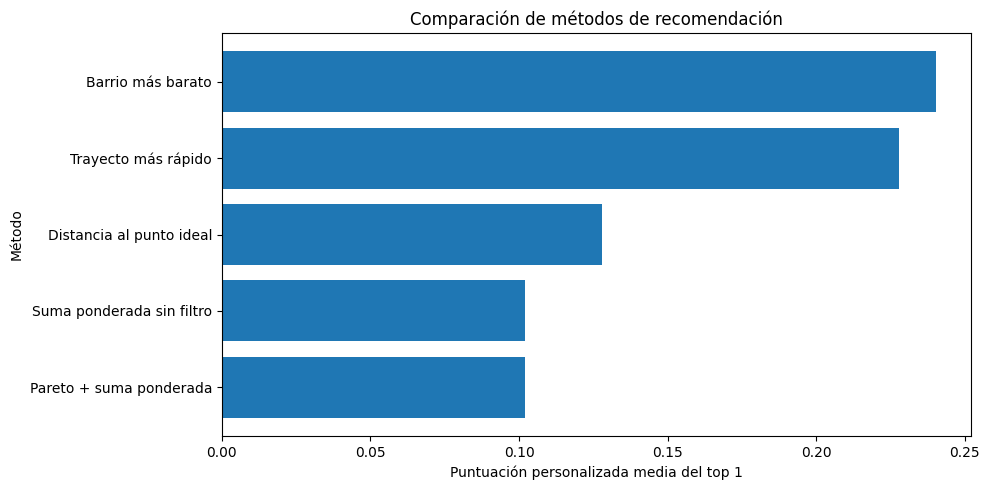

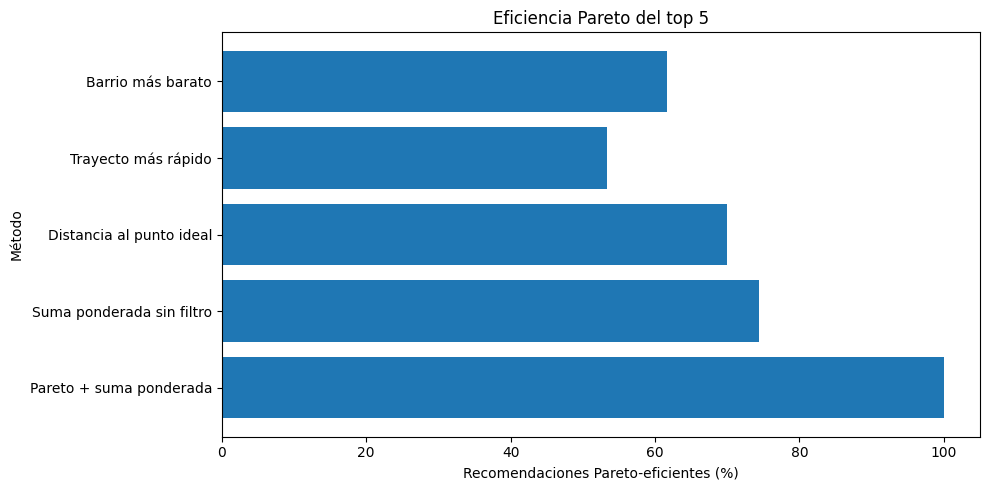

In [23]:
plot_data = (
    method_comparison_summary
    .sort_values(
        "mean_top1_personalized_score",
        ascending=True,
    )
)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["method_label"],
    plot_data["mean_top1_personalized_score"],
)
plt.xlabel("Puntuación personalizada media del top 1")
plt.ylabel("Método")
plt.title("Comparación de métodos de recomendación")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["method_label"],
    plot_data["pareto_efficiency_rate"],
)
plt.xlabel("Recomendaciones Pareto-eficientes (%)")
plt.ylabel("Método")
plt.title(f"Eficiencia Pareto del top {TOP_K}")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()


## 9. Diversidad, cobertura y efecto de la personalización

La personalización debe producir cambios observables en las recomendaciones. Se estudian:

- cobertura del catálogo;
- diversidad de distritos;
- número de grupos destino–modo en los que el ganador cambia entre perfiles;
- comportamiento separado por modo de transporte.


In [24]:
total_neighborhoods = data["zone_key"].nunique()
total_districts = data["district_name"].nunique()

diversity_summary = (
    method_comparison_detail.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        unique_neighborhoods=("zone_key", "nunique"),
        unique_districts=("district_name", "nunique"),
    )
)

diversity_summary["catalog_coverage_pct"] = (
    100
    * diversity_summary["unique_neighborhoods"]
    / total_neighborhoods
)

diversity_summary["district_coverage_pct"] = (
    100
    * diversity_summary["unique_districts"]
    / total_districts
)

profile_dependence_rows = []

for method in METHODS:
    method_top1 = top1_method_results.loc[
        top1_method_results["method"].eq(method)
    ]

    for group_key, group in method_top1.groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        sort=False,
    ):
        winners = (
            group.sort_values("profile_id")[
                "zone_key"
            ]
            .astype(str)
            .tolist()
        )

        profile_dependence_rows.append(
            {
                "method": method,
                "method_label": METHOD_LABELS[method],
                "destination_id": group_key[0],
                "destination_name": group_key[1],
                "transport_mode": group_key[2],
                "transport_mode_label": group_key[3],
                "unique_top1_across_profiles": len(set(winners)),
                "changes_with_profile": len(set(winners)) > 1,
            }
        )

profile_dependence = pd.DataFrame(
    profile_dependence_rows
)

profile_dependence_summary = (
    profile_dependence.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        groups_evaluated=("destination_id", "size"),
        groups_changing_with_profile=("changes_with_profile", "sum"),
    )
)

diversity_summary = diversity_summary.merge(
    profile_dependence_summary,
    on=["method", "method_label"],
    how="left",
    validate="one_to_one",
)

display(diversity_summary)
display(profile_dependence.head(20))


,method,method_label,unique_neighborhoods,unique_districts,catalog_coverage_pct,district_coverage_pct,groups_evaluated,groups_changing_with_profile
0,cheapest,Barrio más barato,7,4,5.426357,19.047619,12,0
1,fastest,Trayecto más rápido,30,10,23.255814,47.619048,12,0
2,ideal_distance,Distancia al punto ideal,26,10,20.155039,47.619048,12,0
3,pareto_weighted,Pareto + suma ponderada,43,16,33.333333,76.190476,12,12
4,weighted_all,Suma ponderada sin filtro,48,13,37.209302,61.904762,12,12


,method,method_label,destination_id,destination_name,transport_mode,transport_mode_label,unique_top1_across_profiles,changes_with_profile
0,pareto_weighted,Pareto + suma ponderada,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,3,True
1,pareto_weighted,Pareto + suma ponderada,DEST_001,Puerta del Sol,CAR,Coche,3,True
2,pareto_weighted,Pareto + suma ponderada,DEST_001,Puerta del Sol,TRANSIT,Transporte público,2,True
3,pareto_weighted,Pareto + suma ponderada,DEST_001,Puerta del Sol,WALK,A pie,3,True
4,pareto_weighted,Pareto + suma ponderada,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,3,True
5,pareto_weighted,Pareto + suma ponderada,DEST_002,Nuevos Ministerios,CAR,Coche,3,True
6,pareto_weighted,Pareto + suma ponderada,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,2,True
7,pareto_weighted,Pareto + suma ponderada,DEST_002,Nuevos Ministerios,WALK,A pie,3,True
8,pareto_weighted,Pareto + suma ponderada,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,2,True
9,pareto_weighted,Pareto + suma ponderada,DEST_003,UC3M Campus de Leganés,CAR,Coche,2,True


In [25]:
main_profile_dependence = (
    profile_dependence.loc[
        profile_dependence[
            "method"
        ].eq("pareto_weighted")
    ]
    .copy()
)

personalization_by_mode = (
    main_profile_dependence.groupby(
        [
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        groups=("destination_id", "size"),
        groups_changing_with_profile=("changes_with_profile", "sum"),
    )
)

personalization_by_mode[
    "groups_changing_pct"
] = (
    100
    * personalization_by_mode[
        "groups_changing_with_profile"
    ]
    / personalization_by_mode["groups"]
)

display(personalization_by_mode)


,transport_mode,transport_mode_label,groups,groups_changing_with_profile,groups_changing_pct
0,BICYCLE,Bicicleta,3,3,100.0
1,CAR,Coche,3,3,100.0
2,TRANSIT,Transporte público,3,3,100.0
3,WALK,A pie,3,3,100.0


## 10. Estabilidad ante cambios en los pesos

Se recorre todo el intervalo del peso del precio. El peso del tiempo se define como `1 - peso_precio`.

La prueba se realiza de manera independiente para cada grupo **destino × modo**. Se registra el ganador, el `top 5`, la similitud de Jaccard con el punto anterior y los intervalos de pesos en los que el ganador permanece constante.

Una transición no implica necesariamente inestabilidad: puede representar un umbral real entre dos compromisos eficientes.


In [26]:
number_of_weight_steps = int(
    round(1 / WEIGHT_STEP)
)

weight_values = np.linspace(
    0,
    1,
    number_of_weight_steps + 1,
)

weight_grid_rows = []

for _, group_row in group_catalog.iterrows():
    previous_top_k: list[str] | None = None
    previous_top1: str | None = None

    for price_weight in weight_values:
        time_weight = 1 - float(price_weight)

        ranking, _ = rank_alternatives(
            source=data,
            destination=group_row["destination_id"],
            transport_mode=group_row["transport_mode"],
            method="pareto_weighted",
            price_weight=float(price_weight),
            time_weight=time_weight,
            top_n=TOP_K,
        )

        top_k = ranking["zone_key"].astype(str).tolist()
        top1 = top_k[0]

        weight_grid_rows.append(
            {
                **group_row.to_dict(),
                "price_weight": float(price_weight),
                "time_weight": time_weight,
                "top1_zone_key": top1,
                "top1_neighborhood_name": ranking[
                    "neighborhood_name"
                ].iloc[0],
                "top_k_zone_keys": "|".join(top_k),
                "adjacent_jaccard_at_k": (
                    np.nan
                    if previous_top_k is None
                    else jaccard_at_k(
                        previous_top_k,
                        top_k,
                    )
                ),
                "top1_changed_from_previous": (
                    False
                    if previous_top1 is None
                    else top1 != previous_top1
                ),
            }
        )

        previous_top_k = top_k
        previous_top1 = top1

weight_stability_grid = pd.DataFrame(
    weight_grid_rows
)

display(weight_stability_grid.head(10))


,destination_id,destination_name,transport_mode,transport_mode_label,price_weight,time_weight,top1_zone_key,top1_neighborhood_name,top_k_zone_keys,adjacent_jaccard_at_k,top1_changed_from_previous
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.00,1.00,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,NaN,False
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.01,0.99,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.02,0.98,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.03,0.97,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.04,0.96,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.05,0.95,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
6,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.06,0.94,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
7,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.07,0.93,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
8,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.08,0.92,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False
9,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.09,0.91,MAD-016,Sol,MAD-016|MAD-011|MAD-012|MAD-021|MAD-102,1.0,False


In [27]:
def build_constant_intervals(
    group: pd.DataFrame,
) -> pd.DataFrame:
    """Agrupa pesos consecutivos con el mismo ganador."""

    ordered = (
        group.sort_values("price_weight")
        .reset_index(drop=True)
    )

    rows = []
    interval_start = 0

    for index in range(1, len(ordered) + 1):
        boundary = (
            index == len(ordered)
            or ordered.loc[
                index,
                "top1_zone_key",
            ]
            != ordered.loc[
                index - 1,
                "top1_zone_key",
            ]
        ) if index < len(ordered) else True

        if boundary:
            first = ordered.loc[interval_start]
            last = ordered.loc[index - 1]

            rows.append(
                {
                    "destination_id": first["destination_id"],
                    "destination_name": first["destination_name"],
                    "transport_mode": first["transport_mode"],
                    "transport_mode_label": first["transport_mode_label"],
                    "min_price_weight": first["price_weight"],
                    "max_price_weight": last["price_weight"],
                    "min_time_weight": last["time_weight"],
                    "max_time_weight": first["time_weight"],
                    "zone_key": first["top1_zone_key"],
                    "neighborhood_name": first[
                        "top1_neighborhood_name"
                    ],
                    "weight_points": (
                        index - interval_start
                    ),
                }
            )

            interval_start = index

    return pd.DataFrame(rows)


weight_intervals = pd.concat(
    [
        build_constant_intervals(group)
        for _, group in weight_stability_grid.groupby(
            [
                "destination_id",
                "transport_mode",
            ],
            sort=False,
        )
    ],
    ignore_index=True,
)

weight_stability_summary = (
    weight_stability_grid.groupby(
        GROUP_COLUMNS,
        as_index=False,
    )
    .agg(
        evaluated_weight_points=("price_weight", "size"),
        unique_top1_neighborhoods=("top1_zone_key", "nunique"),
        top1_transitions=("top1_changed_from_previous", "sum"),
        mean_adjacent_jaccard_at_k=("adjacent_jaccard_at_k", "mean"),
        min_adjacent_jaccard_at_k=("adjacent_jaccard_at_k", "min"),
    )
)

display(weight_stability_summary)
display(weight_intervals.head(30))


,destination_id,destination_name,transport_mode,transport_mode_label,evaluated_weight_points,unique_top1_neighborhoods,top1_transitions,mean_adjacent_jaccard_at_k,min_adjacent_jaccard_at_k
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,101,5,4,0.964286,0.428571
1,DEST_001,Puerta del Sol,CAR,Coche,101,6,5,0.970952,0.428571
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,101,4,3,0.970000,0.666667
3,DEST_001,Puerta del Sol,WALK,A pie,101,7,6,0.966667,0.666667
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,101,6,5,0.963333,0.666667
5,DEST_002,Nuevos Ministerios,CAR,Coche,101,6,5,0.970000,0.666667
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,101,7,6,0.983333,0.666667
7,DEST_002,Nuevos Ministerios,WALK,A pie,101,6,5,0.976667,0.666667
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,101,3,2,1.000000,1.000000
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,101,3,2,1.000000,1.000000


,destination_id,destination_name,transport_mode,transport_mode_label,min_price_weight,max_price_weight,min_time_weight,max_time_weight,zone_key,neighborhood_name,weight_points
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.00,0.32,0.68,1.00,MAD-016,Sol,33
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.33,0.58,0.42,0.67,MAD-102,Puerta del Ángel,26
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.59,0.74,0.26,0.41,MAD-123,San Fermín,16
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.75,0.76,0.24,0.25,MAD-121,Orcasitas,2
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.77,1.00,0.00,0.23,MAD-172,San Cristóbal,24
5,DEST_001,Puerta del Sol,CAR,Coche,0.00,0.06,0.94,1.00,MAD-014,Justicia,7
6,DEST_001,Puerta del Sol,CAR,Coche,0.07,0.40,0.60,0.93,MAD-015,Universidad,34
7,DEST_001,Puerta del Sol,CAR,Coche,0.41,0.45,0.55,0.59,MAD-144,Media Legua,5
8,DEST_001,Puerta del Sol,CAR,Coche,0.46,0.72,0.28,0.54,MAD-134,Palomeras Sureste,27
9,DEST_001,Puerta del Sol,CAR,Coche,0.73,0.85,0.15,0.27,MAD-121,Orcasitas,13


In [28]:
stability_by_mode = (
    weight_stability_summary.groupby(
        [
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        destination_groups=("destination_id", "size"),
        mean_adjacent_jaccard_at_k=("mean_adjacent_jaccard_at_k", "mean"),
        total_top1_transitions=("top1_transitions", "sum"),
        mean_unique_top1=("unique_top1_neighborhoods", "mean"),
    )
)

display(stability_by_mode)


,transport_mode,transport_mode_label,destination_groups,mean_adjacent_jaccard_at_k,total_top1_transitions,mean_unique_top1
0,BICYCLE,Bicicleta,3,0.975873,11,4.666667
1,CAR,Coche,3,0.980317,12,5.000000
2,TRANSIT,Transporte público,3,0.984444,10,4.333333
3,WALK,A pie,3,0.981111,13,5.333333


## 11. Robustez frente a restricciones de precio y tiempo

Los límites se construyen mediante cuantiles dentro de cada grupo destino–modo. Esto evita imponer umbrales absolutos idénticos sobre distribuciones con escalas diferentes.

Para cada escenario se recalcula Pareto después de aplicar los filtros. Una alternativa que estaba dominada en el conjunto original puede dejar de estarlo cuando desaparecen otras opciones.


In [29]:
CONSTRAINT_QUANTILES = [
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
]

constraint_rows = []

for _, group_row in group_catalog.iterrows():
    group_frame = build_group_frame(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
    )

    price_thresholds = {
        quantile: float(
            group_frame[
                PRICE_COLUMN
            ].quantile(quantile)
        )
        for quantile in CONSTRAINT_QUANTILES
    }

    time_thresholds = {
        quantile: float(
            group_frame[
                TIME_COLUMN
            ].quantile(quantile)
        )
        for quantile in CONSTRAINT_QUANTILES
    }

    for profile_id, profile in PROFILES.items():
        base_ranking, _ = rank_alternatives(
            source=data,
            destination=group_row["destination_id"],
            transport_mode=group_row["transport_mode"],
            method="pareto_weighted",
            price_weight=profile["price_weight"],
            time_weight=profile["time_weight"],
            top_n=TOP_K,
        )

        base_top1 = str(
            base_ranking["zone_key"].iloc[0]
        )
        base_top_k = set(
            base_ranking[
                "zone_key"
            ].astype(str)
        )

        for price_quantile in CONSTRAINT_QUANTILES:
            for time_quantile in CONSTRAINT_QUANTILES:
                ranking, audit = rank_alternatives(
                    source=data,
                    destination=group_row["destination_id"],
                    transport_mode=group_row["transport_mode"],
                    method="pareto_weighted",
                    price_weight=profile["price_weight"],
                    time_weight=profile["time_weight"],
                    top_n=TOP_K,
                    max_price_m2=price_thresholds[
                        price_quantile
                    ],
                    max_commute_daily_minutes=time_thresholds[
                        time_quantile
                    ],
                )

                feasible = not ranking.empty

                if feasible:
                    current_top_k = set(
                        ranking[
                            "zone_key"
                        ].astype(str)
                    )
                    top1 = str(
                        ranking["zone_key"].iloc[0]
                    )
                    top1_is_pareto = bool(
                        ranking[
                            "is_pareto_eligible"
                        ].iloc[0]
                    )
                    base_retained = (
                        top1 == base_top1
                    )
                    jaccard = jaccard_at_k(
                        base_top_k,
                        current_top_k,
                    )
                else:
                    top1 = None
                    top1_is_pareto = np.nan
                    base_retained = False
                    jaccard = np.nan

                constraint_rows.append(
                    {
                        **group_row.to_dict(),
                        "profile_id": profile_id,
                        "profile_name": profile[
                            "profile_name"
                        ],
                        "price_quantile": price_quantile,
                        "time_quantile": time_quantile,
                        "max_price_m2": price_thresholds[
                            price_quantile
                        ],
                        "max_commute_daily_minutes": time_thresholds[
                            time_quantile
                        ],
                        "feasible": feasible,
                        "eligible_alternatives": audit[
                            "eligible_alternatives"
                        ],
                        "top1_zone_key": top1,
                        "top1_is_pareto": top1_is_pareto,
                        "base_top1_retained": base_retained,
                        "jaccard_vs_unconstrained": jaccard,
                    }
                )

constraint_robustness = pd.DataFrame(
    constraint_rows
)

display(constraint_robustness.head(15))


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,price_quantile,time_quantile,max_price_m2,max_commute_daily_minutes,feasible,eligible_alternatives,top1_zone_key,top1_is_pareto,base_top1_retained,jaccard_vs_unconstrained
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.6,0.6,5472.556,76.763333,True,36,MAD-121,True,True,0.666667
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.6,0.7,5472.556,91.510000,True,44,MAD-121,True,True,0.666667
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.6,0.8,5472.556,99.603333,True,55,MAD-121,True,True,1.000000
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.6,0.9,5472.556,124.360000,True,67,MAD-121,True,True,1.000000
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.6,1.0,5472.556,183.950000,True,77,MAD-121,True,True,1.000000
5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7,0.6,6023.754,76.763333,True,44,MAD-121,True,True,0.666667
6,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7,0.7,6023.754,91.510000,True,54,MAD-121,True,True,0.666667
7,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7,0.8,6023.754,99.603333,True,66,MAD-121,True,True,1.000000
8,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7,0.9,6023.754,124.360000,True,79,MAD-121,True,True,1.000000
9,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7,1.0,6023.754,183.950000,True,90,MAD-121,True,True,1.000000


In [30]:
constraint_robustness_summary = (
    constraint_robustness.groupby(
        [
            *GROUP_COLUMNS,
            "profile_id",
            "profile_name",
        ],
        as_index=False,
    )
    .agg(
        evaluated_scenarios=("feasible", "size"),
        feasible_scenarios=("feasible", "sum"),
        base_top1_retention_rate=("base_top1_retained", "mean"),
        mean_jaccard_vs_unconstrained=("jaccard_vs_unconstrained", "mean"),
    )
)

constraint_robustness_summary[
    "feasibility_rate"
] = (
    constraint_robustness_summary[
        "feasible_scenarios"
    ]
    / constraint_robustness_summary[
        "evaluated_scenarios"
    ]
)

display(constraint_robustness_summary.head(20))


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,evaluated_scenarios,feasible_scenarios,base_top1_retention_rate,mean_jaccard_vs_unconstrained,feasibility_rate
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,25,25,1.0,1.000000,1.0
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,25,25,1.0,0.866667,1.0
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,25,25,0.4,0.557937,1.0
3,DEST_001,Puerta del Sol,CAR,Coche,balanced,Perfil equilibrado,25,25,1.0,0.933333,1.0
4,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,25,25,0.8,0.650000,1.0
5,DEST_001,Puerta del Sol,CAR,Coche,time_priority,Prioridad al tiempo,25,25,0.4,0.526984,1.0
6,DEST_001,Puerta del Sol,TRANSIT,Transporte público,balanced,Perfil equilibrado,25,25,1.0,0.866667,1.0
7,DEST_001,Puerta del Sol,TRANSIT,Transporte público,price_priority,Prioridad al precio,25,25,0.6,0.771429,1.0
8,DEST_001,Puerta del Sol,TRANSIT,Transporte público,time_priority,Prioridad al tiempo,25,25,1.0,0.819048,1.0
9,DEST_001,Puerta del Sol,WALK,A pie,balanced,Perfil equilibrado,25,25,1.0,0.866667,1.0


## 12. Robustez ante pequeños cambios en los datos

Se aplica ruido multiplicativo independiente a precio y tiempo con desviaciones del 2 %, 5 % y 10 %.

Para cada grupo destino–modo y perfil se repite el proceso Monte Carlo con semilla fija. Se mide:

- retención del ganador original;
- presencia del ganador original dentro del `top 5`;
- similitud de Jaccard del `top 5`;
- número y entropía de ganadores.

El experimento recalcula normalización y Pareto después de cada perturbación.


In [31]:
def perturbed_top_k_numpy(
    price_values: np.ndarray,
    time_values: np.ndarray,
    zone_keys: np.ndarray,
    price_weight: float,
    time_weight: float,
    top_k: int,
) -> np.ndarray:
    """Versión NumPy del método principal para Monte Carlo."""

    price_min = price_values.min()
    price_max = price_values.max()
    time_min = time_values.min()
    time_max = time_values.max()

    if np.isclose(price_max, price_min):
        price_normalized = np.zeros_like(
            price_values,
            dtype=float,
        )
    else:
        price_normalized = (
            (price_values - price_min)
            / (price_max - price_min)
        )

    if np.isclose(time_max, time_min):
        time_normalized = np.zeros_like(
            time_values,
            dtype=float,
        )
    else:
        time_normalized = (
            (time_values - time_min)
            / (time_max - time_min)
        )

    pareto_mask = pareto_mask_2d(
        price_values,
        time_values,
    )

    candidate_indices = np.flatnonzero(
        pareto_mask
    )

    candidate_scores = (
        price_weight
        * price_normalized[candidate_indices]
        + time_weight
        * time_normalized[candidate_indices]
    )

    order = np.lexsort(
        (
            zone_keys[candidate_indices],
            time_values[candidate_indices],
            price_values[candidate_indices],
            candidate_scores,
        )
    )

    selected_indices = candidate_indices[
        order[:top_k]
    ]

    return zone_keys[selected_indices]


In [32]:
noise_frequency_rows = []
noise_summary_rows = []

noise_rng = np.random.default_rng(
    RANDOM_SEED
)

for _, group_row in group_catalog.iterrows():
    group_frame = build_group_frame(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
    )

    original_price = group_frame[
        PRICE_COLUMN
    ].to_numpy(dtype=float)

    original_time = group_frame[
        TIME_COLUMN
    ].to_numpy(dtype=float)

    zone_keys = (
        group_frame["zone_key"]
        .astype(str)
        .to_numpy()
    )

    zone_metadata = (
        group_frame[
            [
                "zone_key",
                "neighborhood_name",
                "district_name",
            ]
        ]
        .assign(
            zone_key=lambda frame:
                frame["zone_key"].astype(str)
        )
        .set_index("zone_key")
    )

    for profile_id, profile in PROFILES.items():
        price_weight, time_weight = normalize_weights(
            profile["price_weight"],
            profile["time_weight"],
        )

        base_ranking, _ = rank_alternatives(
            source=data,
            destination=group_row["destination_id"],
            transport_mode=group_row["transport_mode"],
            method="pareto_weighted",
            price_weight=price_weight,
            time_weight=time_weight,
            top_n=TOP_K,
        )

        base_top1 = str(
            base_ranking["zone_key"].iloc[0]
        )
        base_top_k = set(
            base_ranking[
                "zone_key"
            ].astype(str)
        )

        for noise_level in NOISE_LEVELS:
            winner_counter: dict[str, int] = {}
            top_k_counter: dict[str, int] = {}

            base_top1_retained_count = 0
            base_top1_in_top_k_count = 0
            jaccard_values = []

            for _ in range(
                MONTE_CARLO_ITERATIONS
            ):
                price_noise = noise_rng.normal(
                    loc=0.0,
                    scale=noise_level,
                    size=len(original_price),
                )
                time_noise = noise_rng.normal(
                    loc=0.0,
                    scale=noise_level,
                    size=len(original_time),
                )

                perturbed_price = np.clip(
                    original_price
                    * (1 + price_noise),
                    a_min=np.finfo(float).eps,
                    a_max=None,
                )

                perturbed_time = np.clip(
                    original_time
                    * (1 + time_noise),
                    a_min=np.finfo(float).eps,
                    a_max=None,
                )

                top_k_array = perturbed_top_k_numpy(
                    price_values=perturbed_price,
                    time_values=perturbed_time,
                    zone_keys=zone_keys,
                    price_weight=price_weight,
                    time_weight=time_weight,
                    top_k=TOP_K,
                )

                top_k = (
                    top_k_array
                    .astype(str)
                    .tolist()
                )

                winner = top_k[0]

                winner_counter[winner] = (
                    winner_counter.get(
                        winner,
                        0,
                    )
                    + 1
                )

                for zone_key in top_k:
                    top_k_counter[zone_key] = (
                        top_k_counter.get(
                            zone_key,
                            0,
                        )
                        + 1
                    )

                base_top1_retained_count += (
                    winner == base_top1
                )

                base_top1_in_top_k_count += (
                    base_top1 in top_k
                )

                jaccard_values.append(
                    jaccard_at_k(
                        base_top_k,
                        top_k,
                    )
                )

            winner_counts = pd.Series(
                winner_counter,
                dtype=int,
            )

            observed_zone_keys = sorted(
                set(winner_counter)
                | set(top_k_counter)
            )

            for zone_key in observed_zone_keys:
                metadata = zone_metadata.loc[
                    zone_key
                ]

                wins = winner_counter.get(
                    zone_key,
                    0,
                )

                top_k_appearances = (
                    top_k_counter.get(
                        zone_key,
                        0,
                    )
                )

                noise_frequency_rows.append(
                    {
                        **group_row.to_dict(),
                        "profile_id": profile_id,
                        "profile_name": profile[
                            "profile_name"
                        ],
                        "noise_level": noise_level,
                        "zone_key": zone_key,
                        "neighborhood_name": metadata[
                            "neighborhood_name"
                        ],
                        "district_name": metadata[
                            "district_name"
                        ],
                        "winner_count": int(wins),
                        "winner_frequency": (
                            wins
                            / MONTE_CARLO_ITERATIONS
                        ),
                        "top_k_count": int(
                            top_k_appearances
                        ),
                        "top_k_frequency": (
                            top_k_appearances
                            / MONTE_CARLO_ITERATIONS
                        ),
                        "is_base_top1": (
                            zone_key == base_top1
                        ),
                    }
                )

            noise_summary_rows.append(
                {
                    **group_row.to_dict(),
                    "profile_id": profile_id,
                    "profile_name": profile[
                        "profile_name"
                    ],
                    "noise_level": noise_level,
                    "iterations": MONTE_CARLO_ITERATIONS,
                    "base_top1_zone_key": base_top1,
                    "base_top1_neighborhood_name": base_ranking[
                        "neighborhood_name"
                    ].iloc[0],
                    "base_top1_retention_rate": (
                        base_top1_retained_count
                        / MONTE_CARLO_ITERATIONS
                    ),
                    "base_top1_in_top_k_rate": (
                        base_top1_in_top_k_count
                        / MONTE_CARLO_ITERATIONS
                    ),
                    "mean_jaccard_at_k": float(
                        np.mean(
                            jaccard_values
                        )
                    ),
                    "unique_winners": len(
                        winner_counter
                    ),
                    "winner_entropy": normalized_entropy(
                        winner_counts
                    ),
                }
            )

noise_winner_frequency = pd.DataFrame(
    noise_frequency_rows
)

noise_robustness_summary = pd.DataFrame(
    noise_summary_rows
)

display(
    noise_robustness_summary.head(15)
)


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,noise_level,iterations,base_top1_zone_key,base_top1_neighborhood_name,base_top1_retention_rate,base_top1_in_top_k_rate,mean_jaccard_at_k,unique_winners,winner_entropy
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.02,250,MAD-121,Orcasitas,0.404,0.892,0.791810,4,0.957660
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.05,250,MAD-121,Orcasitas,0.304,0.764,0.603571,8,0.773693
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.10,250,MAD-121,Orcasitas,0.160,0.472,0.357349,22,0.786117
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.02,250,MAD-102,Puerta del Ángel,0.996,1.000,0.660190,2,0.037622
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.05,250,MAD-102,Puerta del Ángel,0.696,0.988,0.498540,8,0.537693
5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.10,250,MAD-102,Puerta del Ángel,0.296,0.812,0.330333,22,0.743166
6,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.02,250,MAD-016,Sol,1.000,1.000,0.863619,1,0.000000
7,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.05,250,MAD-016,Sol,0.992,1.000,0.700429,2,0.067222
8,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.10,250,MAD-016,Sol,0.800,0.980,0.520413,10,0.358956
9,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,0.02,250,MAD-121,Orcasitas,0.556,0.928,0.575429,5,0.707327


In [33]:
noise_global_summary = (
    noise_robustness_summary.groupby(
        "noise_level",
        as_index=False,
    )
    .agg(
        scenarios=("destination_id", "size"),
        mean_base_top1_retention_rate=("base_top1_retention_rate", "mean"),
        mean_base_top1_in_top_k_rate=("base_top1_in_top_k_rate", "mean"),
        mean_jaccard_at_k=("mean_jaccard_at_k", "mean"),
        mean_unique_winners=("unique_winners", "mean"),
        mean_winner_entropy=("winner_entropy", "mean"),
    )
)

noise_mode_summary = (
    noise_robustness_summary.groupby(
        [
            "transport_mode",
            "transport_mode_label",
            "noise_level",
        ],
        as_index=False,
    )
    .agg(
        scenarios=("destination_id", "size"),
        mean_base_top1_retention_rate=("base_top1_retention_rate", "mean"),
        mean_base_top1_in_top_k_rate=("base_top1_in_top_k_rate", "mean"),
        mean_jaccard_at_k=("mean_jaccard_at_k", "mean"),
    )
)

display(noise_global_summary)
display(noise_mode_summary)


,noise_level,scenarios,mean_base_top1_retention_rate,mean_base_top1_in_top_k_rate,mean_jaccard_at_k,mean_unique_winners,mean_winner_entropy
0,0.02,36,0.852333,0.987444,0.813660,2.277778,0.364903
1,0.05,36,0.692222,0.936778,0.632629,5.361111,0.484422
2,0.10,36,0.492000,0.809778,0.448539,14.055556,0.598084


,transport_mode,transport_mode_label,noise_level,scenarios,mean_base_top1_retention_rate,mean_base_top1_in_top_k_rate,mean_jaccard_at_k
0,BICYCLE,Bicicleta,0.02,9,0.839111,0.988000,0.809050
1,BICYCLE,Bicicleta,0.05,9,0.724000,0.962667,0.643074
2,BICYCLE,Bicicleta,0.10,9,0.512889,0.838667,0.447096
3,CAR,Coche,0.02,9,0.825778,0.980889,0.823477
4,CAR,Coche,0.05,9,0.656000,0.880889,0.628690
5,CAR,Coche,0.10,9,0.467556,0.744889,0.418823
6,TRANSIT,Transporte público,0.02,9,0.908889,0.999556,0.772129
7,TRANSIT,Transporte público,0.05,9,0.736000,0.988889,0.603956
8,TRANSIT,Transporte público,0.10,9,0.498222,0.856444,0.445632
9,WALK,A pie,0.02,9,0.835556,0.981333,0.849984


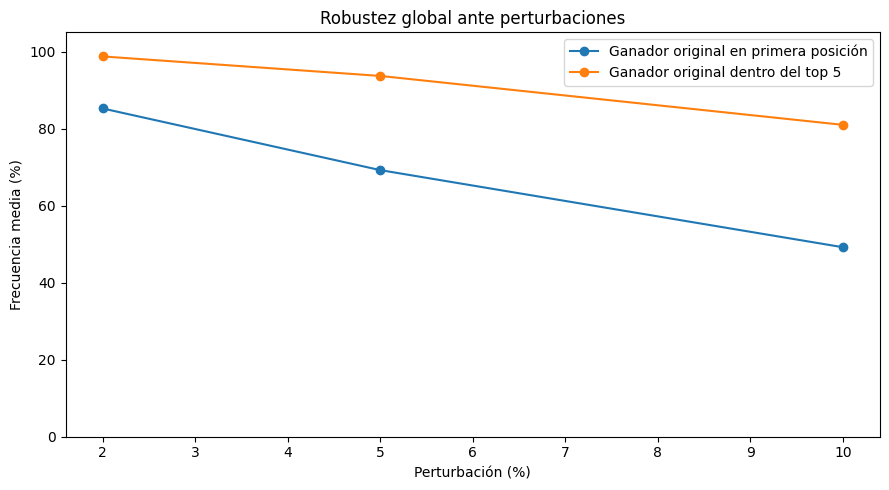

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(
    100 * noise_global_summary["noise_level"],
    100 * noise_global_summary[
        "mean_base_top1_retention_rate"
    ],
    marker="o",
    label="Ganador original en primera posición",
)
plt.plot(
    100 * noise_global_summary["noise_level"],
    100 * noise_global_summary[
        "mean_base_top1_in_top_k_rate"
    ],
    marker="o",
    label=f"Ganador original dentro del top {TOP_K}",
)
plt.xlabel("Perturbación (%)")
plt.ylabel("Frecuencia media (%)")
plt.title("Robustez global ante perturbaciones")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Comparación de robustez entre modos

El análisis multimodal permite comprobar si la estabilidad del recomendador depende del medio de transporte.

Estas tablas son descriptivas: no convierten el modo en un objetivo adicional ni establecen que un modo sea intrínsecamente mejor que otro.


In [35]:
main_method_rows = (
    method_comparison_detail.loc[
        method_comparison_detail[
            "method"
        ].eq("pareto_weighted")
    ]
    .copy()
)

mode_robustness_summary = (
    noise_mode_summary.merge(
        stability_by_mode,
        on=[
            "transport_mode",
            "transport_mode_label",
        ],
        how="left",
        validate="many_to_one",
    )
)

display(mode_robustness_summary)


,transport_mode,transport_mode_label,noise_level,scenarios,mean_base_top1_retention_rate,mean_base_top1_in_top_k_rate,mean_jaccard_at_k,destination_groups,mean_adjacent_jaccard_at_k,total_top1_transitions,mean_unique_top1
0,BICYCLE,Bicicleta,0.02,9,0.839111,0.988000,0.809050,3,0.975873,11,4.666667
1,BICYCLE,Bicicleta,0.05,9,0.724000,0.962667,0.643074,3,0.975873,11,4.666667
2,BICYCLE,Bicicleta,0.10,9,0.512889,0.838667,0.447096,3,0.975873,11,4.666667
3,CAR,Coche,0.02,9,0.825778,0.980889,0.823477,3,0.980317,12,5.000000
4,CAR,Coche,0.05,9,0.656000,0.880889,0.628690,3,0.980317,12,5.000000
5,CAR,Coche,0.10,9,0.467556,0.744889,0.418823,3,0.980317,12,5.000000
6,TRANSIT,Transporte público,0.02,9,0.908889,0.999556,0.772129,3,0.984444,10,4.333333
7,TRANSIT,Transporte público,0.05,9,0.736000,0.988889,0.603956,3,0.984444,10,4.333333
8,TRANSIT,Transporte público,0.10,9,0.498222,0.856444,0.445632,3,0.984444,10,4.333333
9,WALK,A pie,0.02,9,0.835556,0.981333,0.849984,3,0.981111,13,5.333333


## 14. Evaluación de las hipótesis

Las hipótesis se evalúan de forma automática a partir de los resultados reales. Una hipótesis no superada no se oculta ni invalida por sí sola el sistema: identifica una propiedad concreta que debe interpretarse y discutirse.


In [36]:
# H1 — eficiencia Pareto del método principal.
h1_value = main_method_rows[
    "is_pareto_eligible"
].mean()

h1_passed = np.isclose(
    h1_value,
    1.0,
)

# H2 — estabilidad local ante cambios consecutivos de pesos.
h2_value = (
    weight_stability_grid[
        "adjacent_jaccard_at_k"
    ]
    .dropna()
    .mean()
)

h2_passed = h2_value >= 0.70

# H3 — robustez con ruido del 5 %.
noise_5 = (
    noise_robustness_summary.loc[
        np.isclose(
            noise_robustness_summary[
                "noise_level"
            ],
            0.05,
        )
    ]
)

h3_value = noise_5[
    "base_top1_in_top_k_rate"
].mean()

h3_passed = h3_value >= 0.80

# H4 — efecto real de la personalización.
h4_value = int(
    main_profile_dependence[
        "changes_with_profile"
    ].sum()
)

h4_passed = h4_value >= 1

# H5 — eficiencia bajo restricciones factibles.
feasible_constraint_rows = (
    constraint_robustness.loc[
        constraint_robustness["feasible"]
    ]
)

h5_value = (
    feasible_constraint_rows[
        "top1_is_pareto"
    ].astype(bool).mean()
)

h5_passed = np.isclose(
    h5_value,
    1.0,
)


In [37]:
hypothesis_results = pd.DataFrame(
    [
        {
            "hypothesis_id": "H1",
            "hypothesis": (
                "Las recomendaciones del método principal "
                "son Pareto-eficientes."
            ),
            "metric": "pareto_efficiency_rate",
            "value": float(h1_value),
            "criterion": "== 1.00",
            "passed": bool(h1_passed),
        },
        {
            "hypothesis_id": "H2",
            "hypothesis": (
                "El top 5 es estable ante pequeños cambios "
                "consecutivos en los pesos."
            ),
            "metric": "mean_adjacent_jaccard_at_k",
            "value": float(h2_value),
            "criterion": ">= 0.70",
            "passed": bool(h2_passed),
        },
        {
            "hypothesis_id": "H3",
            "hypothesis": (
                "Con ruido del 5 %, el ganador original "
                "permanece dentro del top 5."
            ),
            "metric": "base_top1_in_top5_rate",
            "value": float(h3_value),
            "criterion": ">= 0.80",
            "passed": bool(h3_passed),
        },
        {
            "hypothesis_id": "H4",
            "hypothesis": (
                "La personalización modifica el ganador "
                "en al menos un grupo destino–modo."
            ),
            "metric": "groups_changing_with_profile",
            "value": float(h4_value),
            "criterion": ">= 1",
            "passed": bool(h4_passed),
        },
        {
            "hypothesis_id": "H5",
            "hypothesis": (
                "Los escenarios restringidos factibles "
                "mantienen eficiencia Pareto."
            ),
            "metric": "constraint_pareto_rate",
            "value": float(h5_value),
            "criterion": "== 1.00",
            "passed": bool(h5_passed),
        },
    ]
)

display(hypothesis_results)

passed_hypotheses = int(
    hypothesis_results["passed"].sum()
)

print(
    f"Hipótesis superadas: "
    f"{passed_hypotheses}/{len(hypothesis_results)}"
)


,hypothesis_id,hypothesis,metric,value,criterion,passed
0,H1,Las recomendaciones del método principal son Pareto-eficientes.,pareto_efficiency_rate,1.000000,== 1.00,True
1,H2,El top 5 es estable ante pequeños cambios consecutivos en los pesos.,mean_adjacent_jaccard_at_k,0.980437,>= 0.70,True
2,H3,"Con ruido del 5 %, el ganador original permanece dentro del top 5.",base_top1_in_top5_rate,0.936778,>= 0.80,True
3,H4,La personalización modifica el ganador en al menos un grupo destino–modo.,groups_changing_with_profile,12.000000,>= 1,True
4,H5,Los escenarios restringidos factibles mantienen eficiencia Pareto.,constraint_pareto_rate,1.000000,== 1.00,True


Hipótesis superadas: 5/5


## 15. Validaciones automáticas

Estas comprobaciones son estructurales y deben superarse para exportar la evaluación. A diferencia de las hipótesis, una validación fallida indica una incoherencia del experimento o de los datos.


In [38]:
validation_rows = []


def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )


In [39]:
add_validation(
    "unique_input_alternatives",
    "Cada combinación barrio–destino–modo es única.",
    not data.duplicated(ALT_KEY).any(),
    f"Filas de entrada: {len(data)}",
)

add_validation(
    "expected_transport_modes",
    "Están presentes exactamente los cuatro modos previstos.",
    set(data["transport_mode"].astype(str).unique())
    == EXPECTED_TRANSPORT_MODES,
    f"Presentes: {sorted(present_modes)}",
)

add_validation(
    "complete_destination_mode_matrix",
    "La matriz destino–modo está completa.",
    len(group_catalog) == expected_group_count,
    (
        f"Esperadas: {expected_group_count}; "
        f"presentes: {len(group_catalog)}"
    ),
)

add_validation(
    "normalized_objectives_in_range",
    "Las normalizaciones heredadas están en [0, 1].",
    (
        data[normalized_columns]
        .ge(-FLOAT_TOLERANCE)
        .all()
        .all()
        and data[normalized_columns]
        .le(1 + FLOAT_TOLERANCE)
        .all()
        .all()
    ),
    "Se comprueban price_normalized y time_normalized.",
)

add_validation(
    "pareto_reproduction",
    "La comprobación independiente reproduce Pareto.",
    np.isclose(
        pareto_reproduction[
            "match_percentage"
        ],
        100,
    ).all(),
    (
        "Coincidencia mínima: "
        f"{pareto_reproduction['match_percentage'].min():.2f} %"
    ),
)


In [40]:
expected_method_groups = (
    len(group_catalog)
    * len(PROFILES)
    * len(METHODS)
)

observed_method_groups = (
    method_comparison_detail[
        [
            "destination_id",
            "transport_mode",
            "profile_id",
            "method",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

valid_method_group_sizes = (
    method_comparison_detail.groupby(
        [
            "destination_id",
            "transport_mode",
            "profile_id",
            "method",
        ]
    )
    .size()
    .between(1, TOP_K)
    .all()
)

add_validation(
    "complete_method_comparison",
    "La comparación contiene todos los escenarios esperados.",
    (
        observed_method_groups
        == expected_method_groups
        and valid_method_group_sizes
    ),
    (
        f"Grupos esperados: {expected_method_groups}; "
        f"grupos obtenidos: {observed_method_groups}"
    ),
)

valid_rank_order = (
    method_comparison_detail.groupby(
        [
            "destination_id",
            "transport_mode",
            "profile_id",
            "method",
        ]
    )["rank"]
    .apply(
        lambda series:
            sorted(series.tolist())
            == list(
                range(
                    1,
                    len(series) + 1,
                )
            )
    )
    .all()
)

add_validation(
    "valid_rank_order",
    "Los rankings empiezan en 1 y no repiten posiciones.",
    valid_rank_order,
    "Comprobación por destino–modo–perfil–método.",
)

add_validation(
    "main_method_pareto_efficiency",
    "El método principal no devuelve alternativas dominadas.",
    main_method_rows[
        "is_pareto_eligible"
    ].all(),
    (
        "Alternativas dominadas: "
        f"{int((~main_method_rows['is_pareto_eligible']).sum())}"
    ),
)

no_cross_mode_mix = (
    method_comparison_detail.groupby(
        [
            "destination_id",
            "transport_mode",
            "profile_id",
            "method",
        ]
    )["transport_mode"]
    .nunique()
    .eq(1)
    .all()
)

add_validation(
    "no_cross_mode_mixing",
    "Ningún ranking mezcla modos de transporte.",
    no_cross_mode_mix,
    "Cada grupo conserva un único transport_mode.",
)


In [41]:
expected_weight_rows = (
    len(group_catalog)
    * (number_of_weight_steps + 1)
)

add_validation(
    "complete_weight_grid",
    "La rejilla de pesos contiene todos los puntos esperados.",
    len(weight_stability_grid)
    == expected_weight_rows,
    (
        f"Esperadas: {expected_weight_rows}; "
        f"obtenidas: {len(weight_stability_grid)}"
    ),
)

expected_constraint_rows = (
    len(group_catalog)
    * len(PROFILES)
    * len(CONSTRAINT_QUANTILES) ** 2
)

add_validation(
    "complete_constraint_grid",
    "La rejilla de restricciones está completa.",
    len(constraint_robustness)
    == expected_constraint_rows,
    (
        f"Esperadas: {expected_constraint_rows}; "
        f"obtenidas: {len(constraint_robustness)}"
    ),
)

expected_noise_summaries = (
    len(group_catalog)
    * len(PROFILES)
    * len(NOISE_LEVELS)
)

add_validation(
    "complete_noise_experiment",
    "El experimento de ruido cubre todos los escenarios.",
    len(noise_robustness_summary)
    == expected_noise_summaries,
    (
        f"Esperadas: {expected_noise_summaries}; "
        f"obtenidas: {len(noise_robustness_summary)}"
    ),
)

noise_frequency_sums = (
    noise_winner_frequency.groupby(
        [
            "destination_id",
            "transport_mode",
            "profile_id",
            "noise_level",
        ]
    )["winner_frequency"]
    .sum()
)

add_validation(
    "noise_frequency_sums",
    "Las frecuencias de ganador suman uno por escenario.",
    np.allclose(
        noise_frequency_sums.to_numpy(),
        1.0,
    ),
    (
        "Desviación máxima: "
        f"{float(np.abs(noise_frequency_sums - 1).max()):.3e}"
    ),
)


In [42]:
# Determinismo sobre el primer grupo del catálogo.
test_group = group_catalog.iloc[0]

first_run, _ = rank_alternatives(
    source=data,
    destination=test_group["destination_id"],
    transport_mode=test_group["transport_mode"],
    method="pareto_weighted",
    price_weight=0.63,
    time_weight=0.37,
    top_n=TOP_K,
)

second_run, _ = rank_alternatives(
    source=data,
    destination=test_group["destination_id"],
    transport_mode=test_group["transport_mode"],
    method="pareto_weighted",
    price_weight=0.63,
    time_weight=0.37,
    top_n=TOP_K,
)

add_validation(
    "deterministic_ranking",
    "El ranking es determinista.",
    (
        first_run["zone_key"].tolist()
        == second_run["zone_key"].tolist()
    ),
    (
        f"Grupo de prueba: "
        f"{test_group['destination_id']} / "
        f"{test_group['transport_mode']}"
    ),
)

# Pesos extremos: deben seleccionar un mínimo del objetivo correspondiente
# dentro del frente Pareto del grupo.
extreme_checks = []

for _, group_row in group_catalog.iterrows():
    group_frame = build_group_frame(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
    )

    pareto_frame = group_frame.loc[
        pareto_mask_2d(
            group_frame[PRICE_COLUMN],
            group_frame[TIME_COLUMN],
        )
    ]

    price_rank, _ = rank_alternatives(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
        "pareto_weighted",
        1.0,
        0.0,
        top_n=1,
    )

    time_rank, _ = rank_alternatives(
        data,
        group_row["destination_id"],
        group_row["transport_mode"],
        "pareto_weighted",
        0.0,
        1.0,
        top_n=1,
    )

    extreme_checks.append(
        np.isclose(
            price_rank[PRICE_COLUMN].iloc[0],
            pareto_frame[PRICE_COLUMN].min(),
        )
        and np.isclose(
            time_rank[TIME_COLUMN].iloc[0],
            pareto_frame[TIME_COLUMN].min(),
        )
    )

add_validation(
    "extreme_weights",
    "Los pesos extremos seleccionan mínimos de precio y tiempo del frente.",
    all(extreme_checks),
    f"Grupos comprobados: {len(extreme_checks)}",
)


In [43]:
validation_report = pd.DataFrame(
    validation_rows
)

display(validation_report)

failed_validations = (
    validation_report.loc[
        ~validation_report["passed"]
    ]
)

if not failed_validations.empty:
    display(failed_validations)
    raise AssertionError(
        "La evaluación no supera todas "
        "las validaciones automáticas."
    )

print(
    "Todas las validaciones automáticas "
    "se han superado correctamente."
)


,validation_id,description,passed,detail
0,unique_input_alternatives,Cada combinación barrio–destino–modo es única.,True,Filas de entrada: 1457
1,expected_transport_modes,Están presentes exactamente los cuatro modos previstos.,True,"Presentes: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
2,complete_destination_mode_matrix,La matriz destino–modo está completa.,True,Esperadas: 12; presentes: 12
3,normalized_objectives_in_range,"Las normalizaciones heredadas están en [0, 1].",True,Se comprueban price_normalized y time_normalized.
4,pareto_reproduction,La comprobación independiente reproduce Pareto.,True,Coincidencia mínima: 100.00 %
5,complete_method_comparison,La comparación contiene todos los escenarios esperados.,True,Grupos esperados: 180; grupos obtenidos: 180
6,valid_rank_order,Los rankings empiezan en 1 y no repiten posiciones.,True,Comprobación por destino–modo–perfil–método.
7,main_method_pareto_efficiency,El método principal no devuelve alternativas dominadas.,True,Alternativas dominadas: 0
8,no_cross_mode_mixing,Ningún ranking mezcla modos de transporte.,True,Cada grupo conserva un único transport_mode.
9,complete_weight_grid,La rejilla de pesos contiene todos los puntos esperados.,True,Esperadas: 1212; obtenidas: 1212


Todas las validaciones automáticas se han superado correctamente.


## 16. Exportación de resultados

Los archivos se exportan con nombres específicos de la evaluación multimodal para no sobrescribir resultados de versiones anteriores del TFG.


In [44]:
method_comparison_detail.to_csv(
    METHOD_DETAIL_PATH,
    index=False,
    encoding="utf-8-sig",
)

method_comparison_summary.to_csv(
    METHOD_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

method_mode_summary.to_csv(
    METHOD_MODE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_stability_grid.to_csv(
    WEIGHT_GRID_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_stability_summary.to_csv(
    WEIGHT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_intervals.to_csv(
    WEIGHT_INTERVALS_PATH,
    index=False,
    encoding="utf-8-sig",
)

constraint_robustness.to_csv(
    CONSTRAINT_DETAIL_PATH,
    index=False,
    encoding="utf-8-sig",
)

constraint_robustness_summary.to_csv(
    CONSTRAINT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

noise_winner_frequency.to_csv(
    NOISE_FREQUENCY_PATH,
    index=False,
    encoding="utf-8-sig",
)

noise_robustness_summary.to_csv(
    NOISE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

noise_mode_summary.to_csv(
    NOISE_MODE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

diversity_summary.to_csv(
    DIVERSITY_PATH,
    index=False,
    encoding="utf-8-sig",
)

profile_dependence.to_csv(
    PROFILE_DEPENDENCE_PATH,
    index=False,
    encoding="utf-8-sig",
)

hypothesis_results.to_csv(
    HYPOTHESES_PATH,
    index=False,
    encoding="utf-8-sig",
)

validation_report.to_csv(
    VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)


In [45]:
generated_paths = [
    METHOD_DETAIL_PATH,
    METHOD_SUMMARY_PATH,
    METHOD_MODE_SUMMARY_PATH,
    WEIGHT_GRID_PATH,
    WEIGHT_SUMMARY_PATH,
    WEIGHT_INTERVALS_PATH,
    CONSTRAINT_DETAIL_PATH,
    CONSTRAINT_SUMMARY_PATH,
    NOISE_FREQUENCY_PATH,
    NOISE_SUMMARY_PATH,
    NOISE_MODE_SUMMARY_PATH,
    DIVERSITY_PATH,
    PROFILE_DEPENDENCE_PATH,
    HYPOTHESES_PATH,
    VALIDATION_PATH,
]

missing_exports = [
    path
    for path in generated_paths
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado todos los archivos esperados: "
        f"{missing_exports}"
    )

print("Archivos generados correctamente:")
for path in generated_paths:
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )


Archivos generados correctamente:
- data\results\evaluation_multimodal_method_comparison_detail.csv
- data\results\evaluation_multimodal_method_comparison_summary.csv
- data\results\evaluation_multimodal_method_summary_by_mode.csv
- data\results\evaluation_multimodal_weight_stability_grid.csv
- data\results\evaluation_multimodal_weight_stability_summary.csv
- data\results\evaluation_multimodal_weight_stability_intervals.csv
- data\results\evaluation_multimodal_constraint_robustness.csv
- data\results\evaluation_multimodal_constraint_robustness_summary.csv
- data\results\evaluation_multimodal_noise_winner_frequency.csv
- data\results\evaluation_multimodal_noise_robustness_summary.csv
- data\results\evaluation_multimodal_noise_summary_by_mode.csv
- data\results\evaluation_multimodal_diversity_summary.csv
- data\results\evaluation_multimodal_profile_dependence.csv
- data\results\evaluation_multimodal_hypotheses.csv
- data\results\evaluation_multimodal_validation_report.csv


## 17. Conclusiones finales

La conclusión se genera a partir de los resultados reales. Se separan las **validaciones estructurales**, que deben pasar todas, de las **hipótesis experimentales**, cuyos resultados se interpretan como evidencia empírica y no se fuerzan artificialmente.


In [46]:
mean_weight_jaccard = float(
    weight_stability_grid[
        "adjacent_jaccard_at_k"
    ]
    .dropna()
    .mean()
)

top1_transitions_total = int(
    weight_stability_summary[
        "top1_transitions"
    ].sum()
)

noise_5_row = (
    noise_global_summary.loc[
        np.isclose(
            noise_global_summary[
                "noise_level"
            ],
            0.05,
        )
    ]
    .iloc[0]
)

main_diversity = (
    diversity_summary.loc[
        diversity_summary[
            "method"
        ].eq("pareto_weighted")
    ]
    .iloc[0]
)

display(
    Markdown(
        f"""
La evaluación utiliza **{len(data)} alternativas barrio–destino–modo**, distribuidas en **{len(group_catalog)} grupos destino–modo** y cubriendo los cuatro medios de transporte.

El método principal presenta una eficiencia Pareto del **{pareto_method_summary['pareto_efficiency_rate']:.2f} %** en las recomendaciones evaluadas. La personalización modifica la primera recomendación en **{int(main_profile_dependence['changes_with_profile'].sum())} de {len(main_profile_dependence)} grupos destino–modo**.

La sensibilidad a los pesos alcanza una similitud media consecutiva de **{mean_weight_jaccard:.3f}** en el `top {TOP_K}` y acumula **{top1_transitions_total} cambios de primera recomendación** a lo largo de toda la rejilla.

Con perturbaciones del **5 %**, el ganador original permanece dentro del `top {TOP_K}` en promedio en el **{100 * noise_5_row['mean_base_top1_in_top_k_rate']:.2f} %** de las iteraciones. La cobertura del método principal alcanza **{main_diversity['catalog_coverage_pct']:.2f} %** de los barrios disponibles en el dataset de evaluación.

Se superan **{passed_hypotheses} de {len(hypothesis_results)} hipótesis operativas**. Las hipótesis no superadas, si las hubiera, deben interpretarse como evidencia de sensibilidad del sistema y no ocultarse mediante ajustes posteriores de los umbrales.

Todas las validaciones estructurales se han superado, por lo que los resultados exportados son internamente coherentes y reproducibles.
"""
    )
)



La evaluación utiliza **1457 alternativas barrio–destino–modo**, distribuidas en **12 grupos destino–modo** y cubriendo los cuatro medios de transporte.

El método principal presenta una eficiencia Pareto del **100.00 %** en las recomendaciones evaluadas. La personalización modifica la primera recomendación en **12 de 12 grupos destino–modo**.

La sensibilidad a los pesos alcanza una similitud media consecutiva de **0.980** en el `top 5` y acumula **46 cambios de primera recomendación** a lo largo de toda la rejilla.

Con perturbaciones del **5 %**, el ganador original permanece dentro del `top 5` en promedio en el **93.68 %** de las iteraciones. La cobertura del método principal alcanza **33.33 %** de los barrios disponibles en el dataset de evaluación.

Se superan **5 de 5 hipótesis operativas**. Las hipótesis no superadas, si las hubiera, deben interpretarse como evidencia de sensibilidad del sistema y no ocultarse mediante ajustes posteriores de los umbrales.

Todas las validaciones estructurales se han superado, por lo que los resultados exportados son internamente coherentes y reproducibles.


In [47]:
final_summary = pd.Series(
    {
        "input_rows": len(data),
        "neighborhoods": data["zone_key"].nunique(),
        "destinations": data["destination_id"].nunique(),
        "transport_modes": data["transport_mode"].nunique(),
        "destination_mode_groups": len(group_catalog),
        "profiles": len(PROFILES),
        "methods": len(METHODS),
        "method_comparison_rows": len(method_comparison_detail),
        "weight_grid_rows": len(weight_stability_grid),
        "constraint_scenarios": len(constraint_robustness),
        "noise_scenarios": len(noise_robustness_summary),
        "monte_carlo_runs": (
            len(noise_robustness_summary)
            * MONTE_CARLO_ITERATIONS
        ),
        "hypotheses_passed": passed_hypotheses,
        "hypotheses_total": len(hypothesis_results),
        "validations_passed": int(
            validation_report["passed"].sum()
        ),
        "validations_total": len(validation_report),
        "exported_files": len(generated_paths),
    }
)

final_summary.to_csv(
    SUMMARY_PATH,
    header=["value"],
    encoding="utf-8-sig",
)

display(
    final_summary.to_frame("value")
)

print(
    "\\nNotebook 10 multimodal "
    "finalizado correctamente."
)


,value
input_rows,1457
neighborhoods,129
destinations,3
transport_modes,4
destination_mode_groups,12
profiles,3
methods,5
method_comparison_rows,891
weight_grid_rows,1212
constraint_scenarios,900


\nNotebook 10 multimodal finalizado correctamente.
